In [ ]:
!pip install torch torchvision opacus

print("Tools installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 8.6 MB/s eta 0:00:00
Tools installed successfully!


In [ ]:
import torch
from torchvision import datasets, transforms
from opacus import PrivacyEngine
from torch import nn, optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

print("Tools imported successfully!")

Tools imported successfully!


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]


In [ ]:
class SimpleCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 16, kernel_size=8, stride=2, padding=3)
    self.conv2 = nn.Conv2d(16, 32, kernel_size=4, stride=2)
    self.fc1 = nn.Linear(32 * 4 * 4, 32)
    self.fc2 = nn.Linear(32, 10)

  def forward(self, x):
    x = torch.relu(self.conv1(x))
    x = torch.max_pool2d(x, 2, 1)
    x = torch.relu(self.conv2(x))
    x = torch.max_pool2d(x, 2, 1)
    x = torch.flatten(x, 1)
    x = torch.relu(self.fc1(x))
    x = self.fc2(x)
    return x

model = SimpleCNN().to(device)

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Start DP-SGD Trainig...
Epoch 1 | Test Accuracy: 91.75% | Privacy Budget (ε): 0.17
Epoch 2 | Test Accuracy: 91.81% | Privacy Budget (ε): 0.23
Epoch 3 | Test Accuracy: 92.02% | Privacy Budget (ε): 0.28
Epoch 4 | Test Accuracy: 91.56% | Privacy Budget (ε): 0.32
Epoch 5 | Test Accuracy: 91.07% | Privacy Budget (ε): 0.35


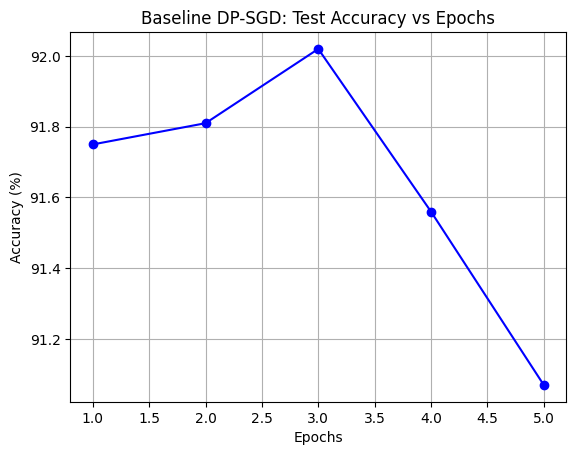

In [ ]:
optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.5)
criterion = nn.CrossEntropyLoss()

model.train()

privacy_engine = PrivacyEngine()
model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=1.0,
    max_grad_norm=1.0,
)

epochs = 5
test_accuracies = []

print("Start DP-SGD Trainig...")
for epoch in range(epochs):
  model.train()
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    output = model(images)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()

  model.eval()
  correct = 0
  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)
      output = model(images)
      pred = output.argmax(dim=1, keepdim=True)
      correct += pred.eq(labels.view_as(pred)).sum().item()

  accuracy = 100. * correct / len(test_loader.dataset)
  test_accuracies.append(accuracy)

  epsilon = privacy_engine.get_epsilon(delta=1e-5)
  print(f"Epoch {epoch+1} | Test Accuracy: {accuracy:.2f}% | Privacy Budget (ε): {epsilon:.2f}")

plt.plot(range(1, epochs+1), test_accuracies, marker='o', color='b')
plt.title('Baseline DP-SGD: Test Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.show()